# Customer Churn Prediction

This notebook builds an end-to-end classification pipeline for predicting customer churn using the IBM Telco Customer Churn dataset.

**Goal:** identify customers who are more likely to leave so a business can target retention efforts more efficiently.


## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
    classification_report
)
import joblib

pd.set_option("display.max_columns", 100)


## 2. Load Dataset

In [2]:
DATA_PATH = Path("Telco-Customer-Churn.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Initial Data Inspection

In [3]:
print(df.info())
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))
print("\nTarget distribution:")
print(df["Churn"].value_counts())
print("\nTarget percentage:")
print(df["Churn"].value_counts(normalize=True).mul(100).round(2))


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 4. Data Cleaning

`TotalCharges` is stored as text because some rows contain blank strings. We convert it to numeric and let the preprocessing pipeline impute missing values.

`customerID` is an identifier rather than a behavioral feature, so it is removed from model training.


In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())

df_model = df.drop(columns=["customerID"]).copy()
df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

df_model.head()


Missing TotalCharges after conversion: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5. Exploratory Data Analysis

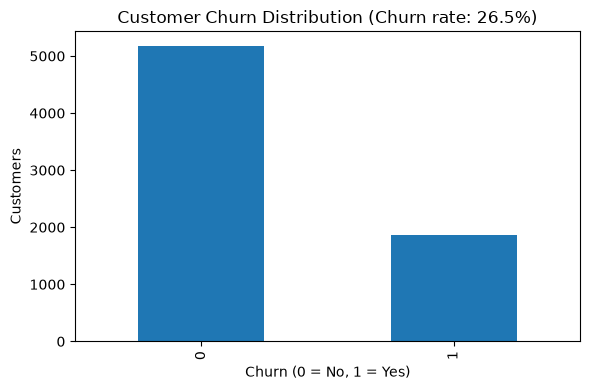

In [5]:
churn_rate = df_model["Churn"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
df_model["Churn"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title(f"Customer Churn Distribution (Churn rate: {churn_rate:.1%})")
ax.set_xlabel("Churn (0 = No, 1 = Yes)")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()


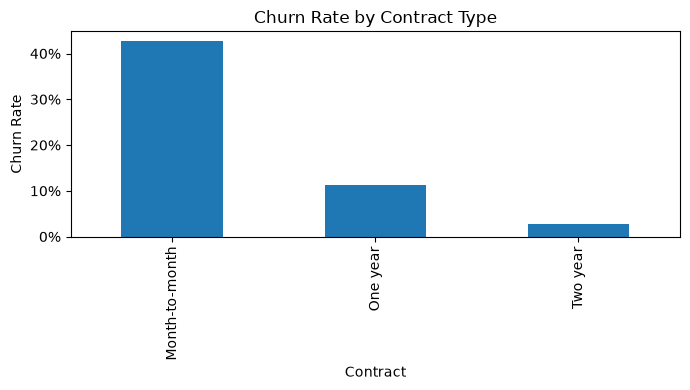

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

In [6]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .apply(lambda s: (s == "Yes").mean())
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
contract_churn.plot(kind="bar", ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract")
ax.set_ylabel("Churn Rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

contract_churn


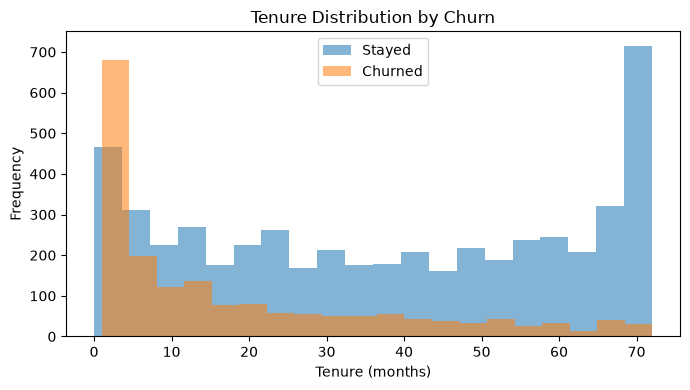

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for churn_value, label in [("No", "Stayed"), ("Yes", "Churned")]:
    df.loc[df["Churn"] == churn_value, "tenure"].plot(
        kind="hist", bins=20, alpha=0.55, ax=ax, label=label
    )
ax.set_title("Tenure Distribution by Churn")
ax.set_xlabel("Tenure (months)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Train/Test Split

In [8]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train churn rate:", round(y_train.mean(), 4))
print("Test churn rate:", round(y_test.mean(), 4))


Training rows: 5634
Test rows: 1409
Train churn rate: 0.2654
Test churn rate: 0.2654


## 7. Preprocessing Pipeline

In [9]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 8. Train Models

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)
    prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8413
1,Random Forest,0.7544,0.5253,0.7781,0.6272,0.8407


## 9. Evaluate the Best Model

In [11]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Best model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, best_pred))


Best model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



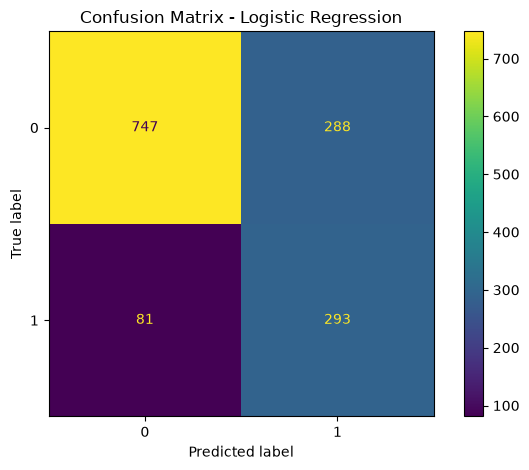

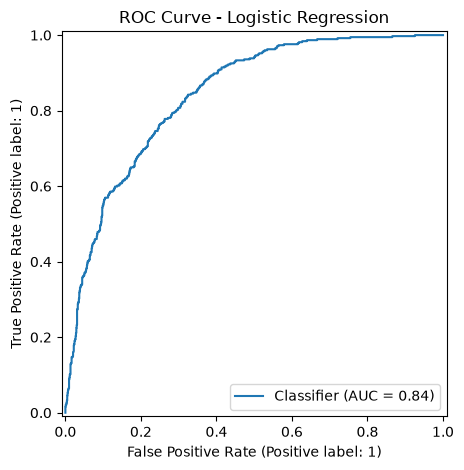

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, best_prob)
plt.title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
plt.show()


## 10. Model Interpretation

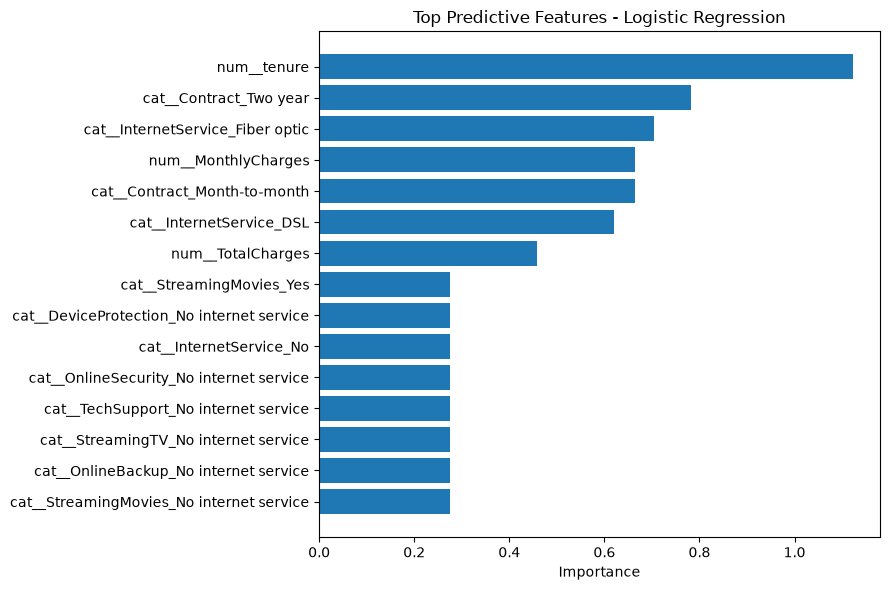

,feature,importance
1,num__tenure,1.123589
38,cat__Contract_Two year,0.781257
16,cat__InternetService_Fiber optic,0.705336
2,num__MonthlyCharges,0.663581
36,cat__Contract_Month-to-month,0.663399
15,cat__InternetService_DSL,0.621009
3,num__TotalCharges,0.457211
35,cat__StreamingMovies_Yes,0.274978
25,cat__DeviceProtection_No internet service,0.274568
17,cat__InternetService_No,0.274568


In [13]:
# Get transformed feature names
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
model = best_model.named_steps["model"]

if hasattr(model, "coef_"):
    importance_values = np.abs(model.coef_[0])
elif hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
else:
    importance_values = None

if importance_values is not None:
    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importance_values})
          .sort_values("importance", ascending=False)
          .head(15)
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
    ax.set_title(f"Top Predictive Features - {best_model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(importance_df)



## 11. Business Interpretation

Use the model as a **prioritization tool**, not as an automatic decision-maker.

A practical retention workflow could be:

1. score active customers weekly or monthly
2. rank customers by predicted churn probability
3. focus outreach on high-risk, high-value customers
4. test different retention offers using controlled experiments
5. track whether the intervention actually reduces churn

Important limitation: this dataset is a fictional IBM sample. A production model would need fresh company-specific data, threshold tuning based on campaign economics, monitoring, and fairness checks.


## 12. Save the Best Model

In [14]:
MODEL_PATH = Path("models/churn_model.joblib")
MODEL_PATH.parent.mkdir(exist_ok=True)

joblib.dump(best_model, MODEL_PATH)

print(f"Saved model to: {MODEL_PATH}")


Saved model to: models\churn_model.joblib


## 13. Example Prediction

The saved pipeline accepts the original feature columns (except `customerID`) and handles preprocessing internally.


In [15]:
sample_customer = X_test.iloc[[0]]

probability = best_model.predict_proba(sample_customer)[:, 1][0]
prediction = best_model.predict(sample_customer)[0]

print("Predicted churn:", "Yes" if prediction == 1 else "No")
print("Churn probability:", round(probability, 4))


Predicted churn: No
Churn probability: 0.1155
